In [164]:
import pandas as pd

In [242]:
df_current = pd.read_csv('기존 신호 시뮬레이션 결과.csv')
df_pso = pd.read_csv('PSO 신호 시뮬레이션 결과.csv')

In [243]:
current_datasets = df_current.iloc[:,1:].values.tolist()
pso_datasets = df_pso.iloc[:,1:].values.tolist()

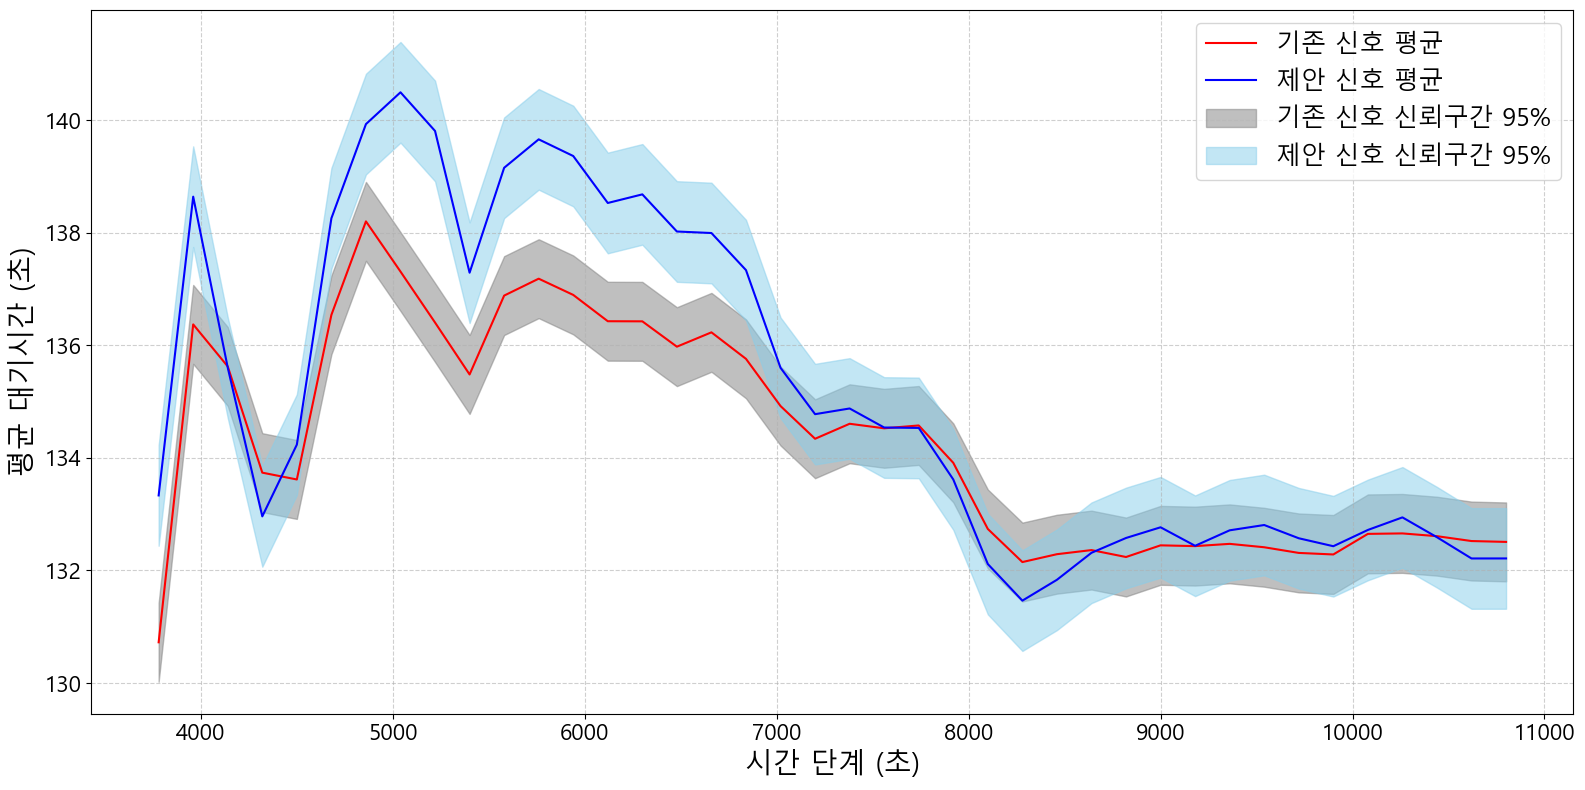

In [253]:
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

df_current = pd.read_csv('기존 신호 시뮬레이션 결과.csv')
df_pso = pd.read_csv('PSO 신호 시뮬레이션 결과.csv')

current_datasets = df_current.iloc[:,1:].values.tolist()
pso_datasets = df_pso.iloc[:,1:].values.tolist()

confidence_level = 0.95
n = len(current_datasets[0])
z = 1.96

upper_combined_current = np.zeros(n)
lower_combined_current = np.zeros(n)
upper_combined_pso = np.zeros(n)
lower_combined_pso = np.zeros(n)
x_values = np.linspace(3780, 10800, n)

# Calculate combined confidence intervals for the 'current' datasets
for i in range(n):
    means_current = [dataset[i] for dataset in current_datasets]
    std_devs_current = [np.std(dataset) for dataset in current_datasets]
    
    margin_errors_current = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_current]
    
    combined_mean_current = np.mean(means_current)
    combined_margin_error_current = np.sqrt(np.sum([error ** 2 for error in margin_errors_current]) / len(current_datasets))
    
    upper_combined_current[i] = combined_mean_current + combined_margin_error_current
    lower_combined_current[i] = combined_mean_current - combined_margin_error_current

# Calculate combined confidence intervals for the 'PSO' datasets
for i in range(n):
    means_pso = [dataset[i] for dataset in pso_datasets]
    std_devs_pso = [np.std(dataset) for dataset in pso_datasets]
    
    margin_errors_pso = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_pso]
    
    # Calculate the combined confidence interval (for the mean of 'PSO' datasets)
    combined_mean_pso = np.mean(means_pso)
    combined_margin_error_pso = np.sqrt(np.sum([error ** 2 for error in margin_errors_pso]) / len(pso_datasets))
    
    upper_combined_pso[i] = combined_mean_pso + combined_margin_error_pso
    lower_combined_pso[i] = combined_mean_pso - combined_margin_error_pso

plt.figure(figsize=(16, 8))

# Plot 'current' datasets
# for i, dataset in enumerate(current_datasets):
#     plt.plot(range(n), dataset, label=f'Current Dataset {i + 1}', linestyle='dashed')

# Plot 'PSO' datasets
# for i, dataset in enumerate(pso_datasets):
#     plt.plot(range(n), dataset, label=f'PSO Dataset {i + 1}')

plt.plot(np.linspace(3780, 10800, 40), [(np.mean([dataset[i] for dataset in current_datasets])) for i in range(n)], label='기존 신호 평균', color='red')
plt.fill_between(np.linspace(3780, 10800, 40), lower_combined_current, upper_combined_current, alpha=0.5, color='gray', label='기존 신호 신뢰구간 95%')

plt.plot(np.linspace(3780, 10800, 40), [(np.mean([dataset[i] for dataset in pso_datasets])) for i in range(n)], label='제안 신호 평균', color='blue')
plt.fill_between(np.linspace(3780, 10800, 40), lower_combined_pso, upper_combined_pso, alpha=0.5, color='skyblue', label='제안 신호 신뢰구간 95%')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=18)
plt.xlabel('시간 단계 (초)', fontsize=20)
plt.ylabel('평균 대기시간 (초)', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [192]:
waiting_result =  [54.63466065712268, 65.56613537598815, 57.21433416604235, 65.55865600168465, 63.76770701871402, 58.62676441967514, 54.1555943593508, 66.13389356789591, 60.2933809813757, 63.24052939838938]
waiting_result1 =  [44.910507443766676, 45.89109850941534, 44.35188921156148, 44.47712250486178, 44.691008523948405, 46.44732251269557, 45.52228920688172, 45.67774571399066, 44.846960739579735, 43.124650854861834]
left_right_result =  [70.60703870494183, 99.54374723087383, 81.31803122582194, 82.11431613334113, 83.5309844532173, 87.11560563678294, 75.42017973694139, 116.29345130636621, 70.83628596557394, 100.16439515675752]
left_right_result1 =  [48.06589031946604, 44.69563089782499, 47.654915653249454, 45.428419333293675, 44.95747283776726, 46.653778245085, 43.84784520668432, 45.94438603104081, 43.72840412376591, 45.96329874818976]
right_left_result =  [75.00246658863489, 80.02698037970927, 75.29884738230798, 104.49802606780854, 96.39373499712353, 75.86733324075377, 67.29102439476016, 77.25253106380728, 75.32011426984347, 74.95951620476]
right_left_result1 =  [41.24420550055886, 43.88934076616359, 41.297690135629416, 42.33150157716206, 42.53442312906269, 46.04397537379081, 43.590810800087304, 46.73923595267863, 43.192281495295155, 44.47065553064711]
up_down_result =  [39.02193408810173, 39.25481110079715, 39.491028292854025, 38.685358027759335, 38.0404768343578, 36.6661720959807, 37.60139308137043, 39.13025968615476, 38.637279909954046, 38.66822590429685]
up_down_result1 =  [46.264422339002635, 45.19210782128211, 43.877619336495506, 45.78432820003076, 45.506187006190785, 44.21391034870887, 43.855137078914524, 47.08213040586456, 46.006519562341296, 42.71593126685628]
down_up_result =  [34.035071517844834, 43.33439800027772, 32.91796972642691, 36.98063463407866, 37.129002916261605, 34.90315233995289, 36.3420705457576, 32.0411054020276, 55.93627968337729, 39.15743646715729]
down_up_result1 =  [44.12243438411355, 49.672434384113494, 44.55983891126242, 44.39974309123728, 45.75945701985839, 48.76103318983454, 50.621858075267205, 43.04865296486612, 46.44928482155256, 39.43289820858216]

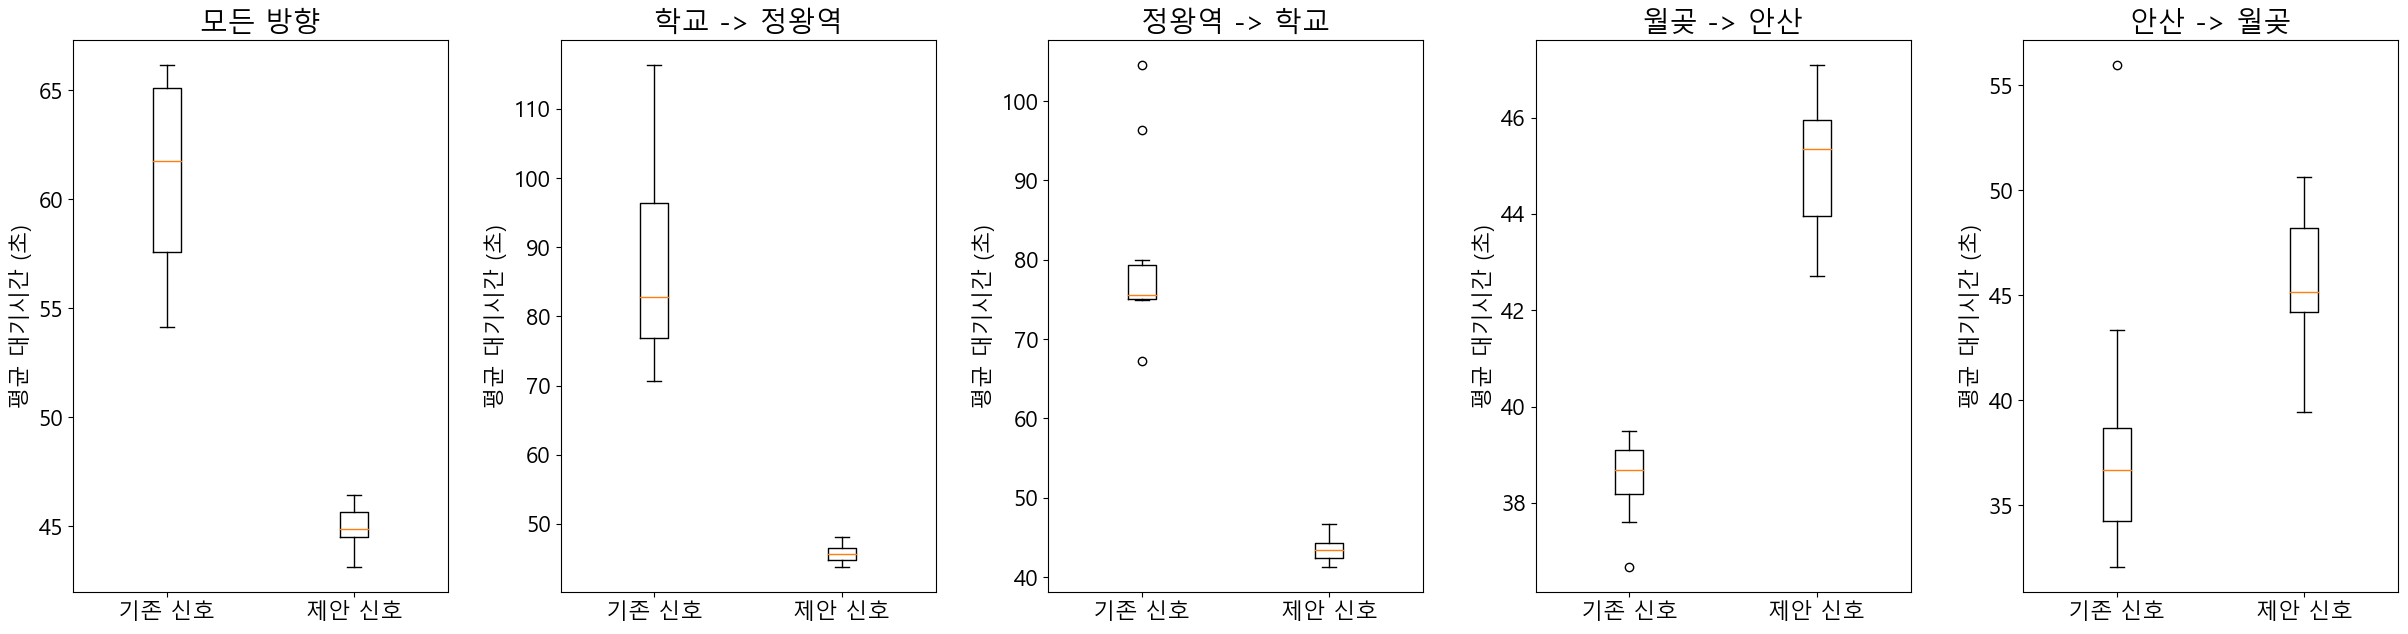

In [7]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

# Group data by categories
waiting_data = [waiting_result, waiting_result1]
left_right_data = [left_right_result, left_right_result1]
right_left_data = [right_left_result, right_left_result1]
up_down_data = [up_down_result, up_down_result1]
down_up_data = [down_up_result, down_up_result1]

data_categories = [waiting_data, left_right_data, right_left_data, up_down_data, down_up_data]
category_names = ['모든 방향', '학교 -> 정왕역', '정왕역 -> 학교', '월곶 -> 안산', '안산 -> 월곶']

# Create subplots with adjusted spacing and increased figure size
fig, axes = plt.subplots(1, 5, figsize=(30, 8), sharey=False, gridspec_kw={'wspace': 0.3})

# Define box style with wider boxes
boxprops = dict(linewidth=2, color='blue')

# Plot each category in a separate subplot
for i, ax in enumerate(axes):
    boxplot = ax.boxplot(data_categories[i])
    for box in boxplot['boxes']:
        box.set(linewidth=1)  # Set the box color and width
    ax.set_title(category_names[i], fontsize=20)
    ax.set_xticklabels(['기존 신호', '제안 신호'], fontsize=16)
    ax.set_ylabel('평균 대기시간 (초)', fontsize=16)
    ax.tick_params(axis='both', labelsize=16)

# Adjust the layout
plt.subplots_adjust(top=0.8)

# Show the plot
plt.show()


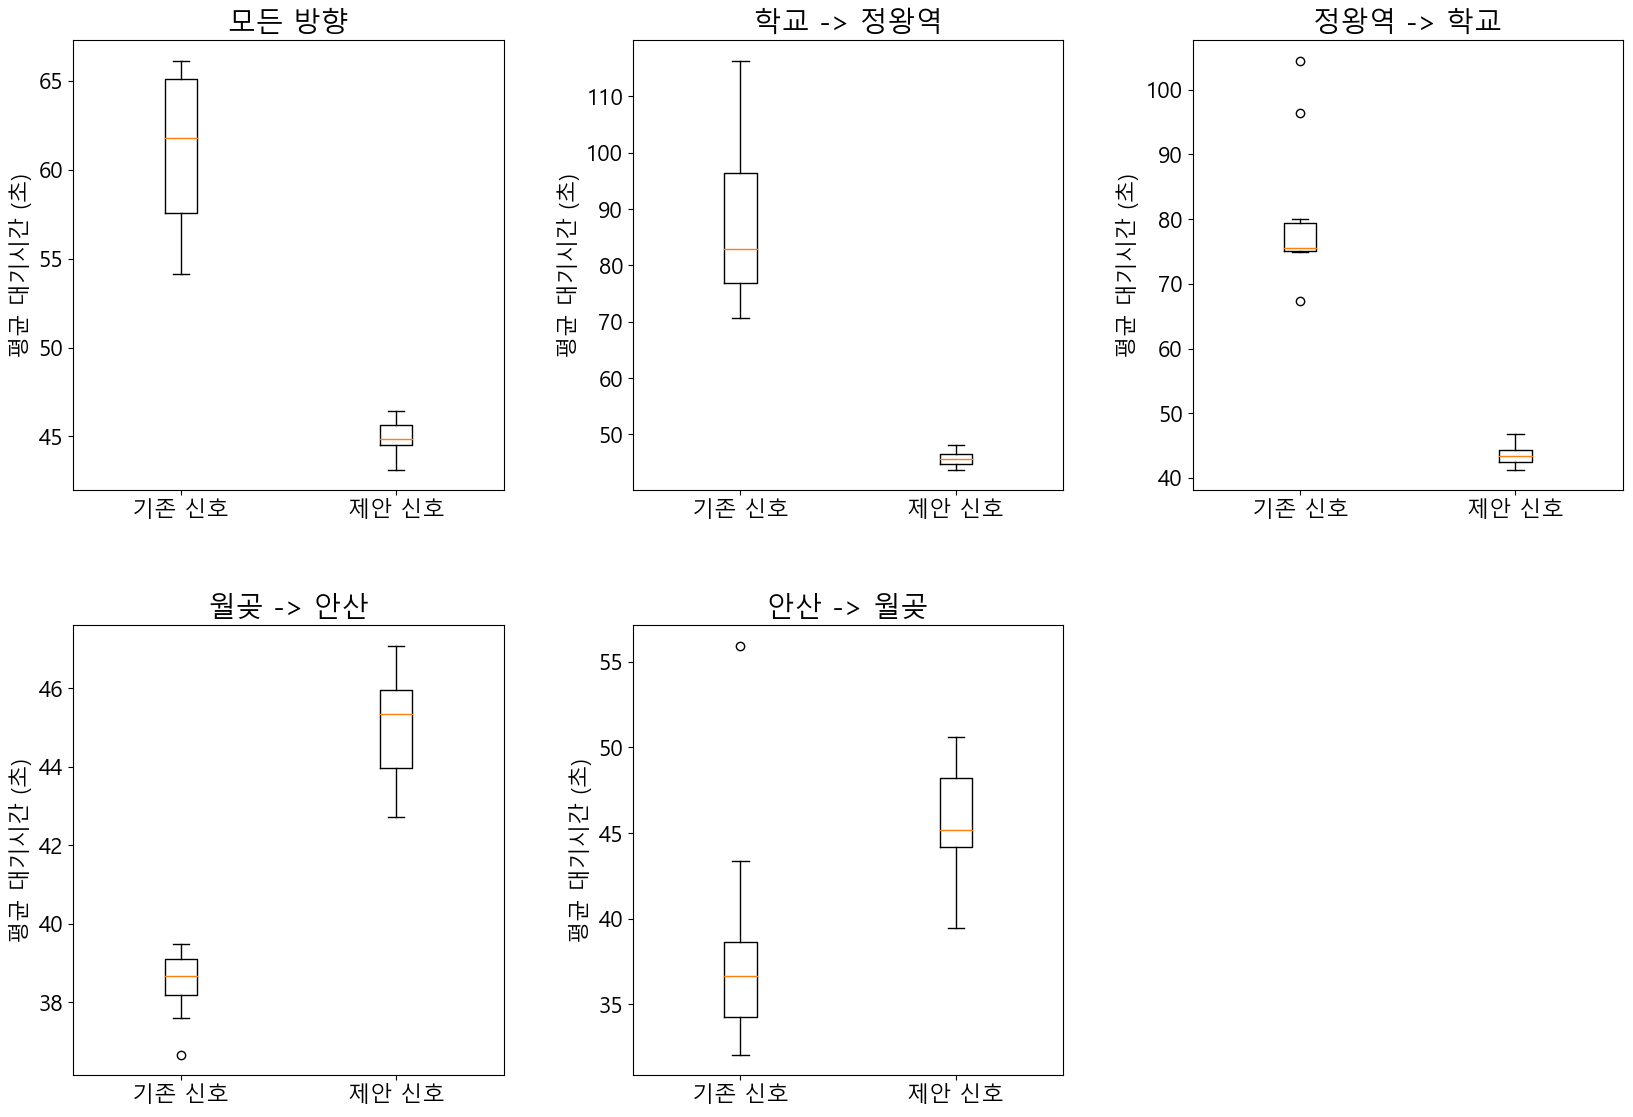

In [8]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

# Group data by categories
waiting_data = [waiting_result, waiting_result1]
left_right_data = [left_right_result, left_right_result1]
right_left_data = [right_left_result, right_left_result1]
up_down_data = [up_down_result, up_down_result1]
down_up_data = [down_up_result, down_up_result1]

data_categories = [waiting_data, left_right_data, right_left_data, up_down_data, down_up_data]
category_names = ['모든 방향', '학교 -> 정왕역', '정왕역 -> 학교', '월곶 -> 안산', '안산 -> 월곶']

# Create subplots with 3 rows and 2 columns
fig, axes = plt.subplots(2, 3, figsize=(20, 15), sharey=False, gridspec_kw={'wspace': 0.3, 'hspace': 0.3})

# Plot each category in separate subplots
for i, ax in enumerate(axes.flat[:-1]):  # Exclude the last subplot
    if i < len(data_categories):
        boxplot = ax.boxplot(data_categories[i])
        for box in boxplot['boxes']:
            box.set(linewidth=1)  # Set the box color and width
        ax.set_title(category_names[i], fontsize=20)
        ax.set_xticklabels(['기존 신호', '제안 신호'], fontsize=16)
        ax.set_ylabel('평균 대기시간 (초)', fontsize=16)
        ax.tick_params(axis='both', labelsize=16)

# Remove the last subplot (3rd row, 2nd column)
fig.delaxes(axes[1, 2])

# Adjust the layout
plt.subplots_adjust(top=0.8)

# Show the plot
plt.show()
